In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [26]:
val_df = pd.read_csv("../input/melanoma/val.csv")
val_df

,image_name,patient_id,features,target
0,ISIC_3536848,IP_5872065,"[1.0, 0.5555555555555556, 0, 0, 0, 0, 1, 0, 0]",0
1,ISIC_3066463,IP_9355893,"[1.0, 0.6111111111111112, 0, 0, 0, 0, 0, 1, 0]",0
2,ISIC_4596182,IP_6029629,"[0.0, 0.5555555555555556, 0, 1, 0, 0, 0, 0, 0]",0
3,ISIC_4748605,IP_1122600,"[0.0, 0.7777777777777778, 0, 0, 0, 0, 0, 1, 0]",0
4,ISIC_5984418,IP_9738076,"[0.0, 0.8333333333333334, 0, 1, 0, 0, 0, 0, 0]",0
...,...,...,...,...
604,ISIC_6087560,IP_1023029,"[0.0, 0.2222222222222222, 0, 0, 0, 0, 0, 1, 0]",0
605,ISIC_0548022,IP_6098503,"[0.0, 0.3333333333333333, 0, 0, 0, 0, 0, 1, 0]",0
606,ISIC_6668859,IP_9115451,"[1.0, 0.7222222222222222, 0, 0, 0, 0, 1, 0, 0]",0
607,ISIC_3824206,IP_8759634,"[0.0, 0.3888888888888889, 0, 0, 0, 0, 1, 0, 0]",1


In [27]:
y_true = []
for i in range(val_df.shape[0]):
    y_true.append(val_df['target'].iloc[i])
#y_true

In [28]:
print(len(y_true))

609


In [29]:
from sklearn.metrics import confusion_matrix
y_pred = [1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
        1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
        1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
        1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
        1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
        1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
        1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
        1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
        1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
        0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
        0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
        1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        1, 1, 1, 1, 0, 0, 0, 1, 1]


    
df_confusion = confusion_matrix(y_true, y_pred)
df_confusion

array([[285, 178],
       [ 14, 132]])

In [30]:
count = 0
for i in range(len(y_pred)):
    if y_pred[i]==1 and y_true[i]==0:
        count+=1
print(count)

178


In [31]:
count = 0
for i in range(len(y_pred)):
    if y_pred[i]==0 and y_true[i]==1:
        count+=1
print(count)

14


In [32]:
df_confusion.sum(axis=1)

array([463, 146])

In [33]:
df_conf_norm = df_confusion / df_confusion.sum(axis=1, keepdims = True)
df_conf_norm 

array([[0.61555076, 0.38444924],
       [0.09589041, 0.90410959]])

confusion matrix


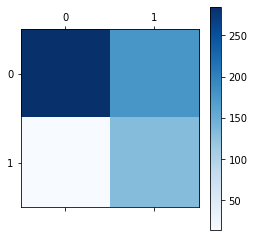

In [34]:
labels = ['benign', 'malignant']
import matplotlib.pyplot as plt
def plot_confusion_matrix(df_confusion, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.matshow(df_confusion, cmap=cmap) # imshow
    #plt.title(title)
    plt.colorbar()
    #tick_marks = np.arange(len(df_confusion.columns))
    #plt.xticks(tick_marks, df_confusion.columns, rotation=45)
    #plt.yticks(tick_marks, df_confusion.index)
    #plt.tight_layout()
    #plt.ylabel(df_confusion.index.name)
    #plt.xlabel(df_confusion.columns.name)

print("confusion matrix")
plot_confusion_matrix(df_confusion)

normalized confusion matrix
[463 146]


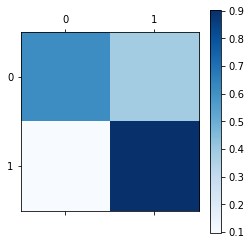

In [35]:
print("normalized confusion matrix")
print(df_confusion.sum(axis=1))
plot_confusion_matrix(df_conf_norm)

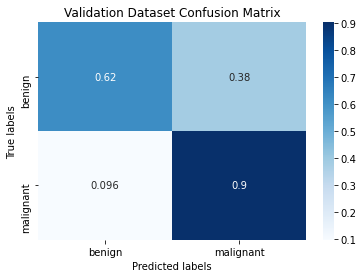

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt     

ax= plt.subplot()
sns.heatmap(df_conf_norm, annot=True, ax = ax, cmap=plt.cm.Blues); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Validation Dataset Confusion Matrix'); 
ax.xaxis.set_ticklabels(['benign', 'malignant']); ax.yaxis.set_ticklabels(['benign', 'malignant']);

In [37]:
fig = ax.get_figure()
fig.savefig("val_conf.png")